In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm

In [2]:
TRAIN_START = "2020-01-01"
TRAIN_END = "2025-06-30"

In [3]:
# Remove SHIB-USD since it has inf value
ticker_universe = ["BTC-USD", "ETH-USD", "BNB-USD", "XRP-USD", "SOL-USD", "TRX-USD", "ZEC-USD", "DOGE-USD", "XMR-USD", "LINK-USD", "ADA-USD", "XLM-USD", "BCH-USD", "LTC-USD", "NEAR-USD", "AVAX-USD", "HBAR-USD", "KCS-USD", "ALGO-USD", "DASH-USD"]

In [4]:
daily_prices = yf.download(tickers=ticker_universe, period="max", interval="1d")

[*********************100%***********************]  20 of 20 completed


In [5]:
daily_returns = (daily_prices["Close"] / daily_prices["Close"].shift() - 1).loc[TRAIN_START:TRAIN_END]
daily_volumes = daily_prices["Volume"].loc[TRAIN_START:TRAIN_END]

In [109]:
def featureX(ticker="BTC-USD"):
    rolling_periods = [14, 28, 45, 60, 90, 120]
    return pd.DataFrame({
        f"{x:03}AVG": daily_returns.shift().rolling(x).mean()[ticker] for x in rolling_periods
    } | {
        f"{x:03}STD": daily_returns.shift().rolling(x).std()[ticker] for x in rolling_periods
    } | {
        f"{x:03}VOL": daily_volumes.pct_change(fill_method=None).shift().rolling(x).mean()[ticker] for x in rolling_periods
    } | {
        f"{x:03}SHP": daily_returns.shift().rolling(x).mean()[ticker] / daily_returns.shift().rolling(x).std()[ticker] for x in rolling_periods
    } | {
        f"{x:03}MUSIG": daily_returns.shift().rolling(x).mean()[ticker] * daily_returns.shift().rolling(x).std()[ticker] for x in rolling_periods
    } | {
        f"{x:03}{y:03}SHPX": daily_returns.shift().rolling(x).mean()[ticker] * daily_returns.shift().rolling(y).std()[ticker] for x in rolling_periods for y in rolling_periods
    }).dropna()

featureX()

,014AVG,028AVG,045AVG,060AVG,090AVG,120AVG,014STD,028STD,045STD,060STD,...,090045SHPX,090060SHPX,090090SHPX,090120SHPX,120014SHPX,120028SHPX,120045SHPX,120060SHPX,120090SHPX,120120SHPX
Date,,,,,,,,,,,,,,,,,,,,,
2020-05-01,0.014772,0.009334,0.013227,0.002858,0.001031,0.003057,0.038915,0.036878,0.046747,0.068692,...,0.000048,0.000071,0.000060,0.000054,0.000119,0.000113,0.000143,0.000210,0.000177,0.000159
2020-05-02,0.016680,0.010501,0.012821,0.002657,0.001245,0.003504,0.038636,0.036797,0.046570,0.068611,...,0.000058,0.000085,0.000072,0.000065,0.000135,0.000129,0.000163,0.000240,0.000203,0.000182
2020-05-03,0.016053,0.010288,0.013077,0.003044,0.001458,0.003192,0.038601,0.036758,0.046543,0.068609,...,0.000068,0.000100,0.000084,0.000076,0.000123,0.000117,0.000149,0.000219,0.000185,0.000165
2020-05-04,0.016000,0.010324,0.008810,0.002936,0.001406,0.003033,0.038638,0.036737,0.038888,0.068624,...,0.000055,0.000096,0.000081,0.000073,0.000117,0.000111,0.000118,0.000208,0.000176,0.000157
2020-05-05,0.019177,0.007857,0.008820,0.002349,0.001559,0.003046,0.035102,0.034795,0.038886,0.068479,...,0.000061,0.000107,0.000090,0.000081,0.000107,0.000106,0.000118,0.000209,0.000176,0.000158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26,-0.000738,0.000006,0.000829,0.002259,0.002564,0.001935,0.017356,0.017842,0.017215,0.017934,...,0.000044,0.000046,0.000058,0.000068,0.000034,0.000035,0.000033,0.000035,0.000044,0.000051
2025-06-27,0.000808,0.000588,0.001022,0.002354,0.002882,0.002316,0.015896,0.017424,0.017111,0.017886,...,0.000049,0.000052,0.000064,0.000075,0.000037,0.000040,0.000040,0.000041,0.000051,0.000060
2025-06-28,0.000784,0.001186,0.000755,0.002157,0.003127,0.002291,0.015895,0.017135,0.017011,0.017831,...,0.000053,0.000056,0.000069,0.000082,0.000036,0.000039,0.000039,0.000041,0.000050,0.000060


In [140]:
weight_lag = 2

In [141]:
def Regression():
    X = pd.concat({ticker: featureX(ticker) for ticker in ticker_universe})
    Y = daily_returns[::-1].rolling(window=weight_lag).sum()[::-1].unstack(level=0).dropna()
    common_index = X.index.intersection(Y.index)
    model = sm.OLS(Y.loc[common_index], X.loc[common_index]).fit()
    return model

regression_model = Regression()

In [142]:
regression_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.021
Model:                            OLS   Adj. R-squared (uncentered):              0.019
Method:                 Least Squares   F-statistic:                              13.27
Date:                Mon, 28 Sep 2026   Prob (F-statistic):                   1.60e-127
Time:                        14:08:48   Log-Likelihood:                          42003.
No. Observations:               37068   AIC:                                 -8.389e+04
Df Residuals:                   37008   BIC:                                 -8.337e+04
Df Model:                          60                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
014AVG        -0.4213      0.130     -3.240      0.001      -0.676      -0.166
028AVG         1.1603      0.293      3.954      0.000       0.585       1.735
045AVG        -0.0172      0.547     -0.031      0.975      -1.090       1.055
060AVG         1.1588      0.757      1.530      0.126      -0.325       2.643
090AVG        -2.0645      1.049     -1.968      0.049      -4.121      -0.008
120AVG        -0.1467      1.019     -0.144      0.886      -2.144       1.850
014STD         0.1797      0.036      4.947      0.000       0.109       0.251
028STD        -0.0394      0.060     -0.660      0.509      -0.156       0.078
045STD        -0.0562      0.083     -0.680      0.496      -0.218       0.106
060STD        -0.1664      0.089     -1.872      0.061      -0.341       0.008
090STD         0.2061      0.088      2.348      0.019       0.034       0.378
120STD        -0.0580      0.067     -0.865      0.387      -0.189       0.073
014VOL        -0.0014      0.001     -0.984      0.325      -0.004       0.001
028VOL         0.0038      0.003      1.444      0.149      -0.001       0.009
045VOL         0.0035      0.004      0.837      0.403      -0.005       0.012
060VOL        -0.0080      0.005     -1.627      0.104      -0.018       0.002
090VOL         0.0062      0.006      1.041      0.298      -0.005       0.018
120VOL         0.0010      0.006      0.184      0.854      -0.010       0.012
014SHP         0.0250      0.004      5.969      0.000       0.017       0.033
028SHP        -0.0193      0.010     -2.025      0.043      -0.038      -0.001
045SHP        -0.0259      0.017     -1.498      0.134      -0.060       0.008
060SHP        -0.0058      0.023     -0.257      0.797      -0.050       0.039
090SHP         0.0220      0.031      0.719      0.472      -0.038       0.082
120SHP         0.0390      0.031      1.271      0.204      -0.021       0.099
014MUSIG       4.2236      0.482      8.762      0.000       3.279       5.168
028MUSIG       1.0332      1.618      0.638      0.523      -2.139       4.205
045MUSIG      -9.2932      3.096     -3.001      0.003     -15.362      -3.225
060MUSIG      19.4351      4.847      4.010      0.000       9.936      28.934
090MUSIG     -27.1770      8.279     -3.283      0.001     -43.403     -10.950
120MUSIG      16.8840      3.855      4.380      0.000       9.329      24.440
014014SHPX     4.2236      0.482      8.762      0.000       3.279       5.168
014028SHPX   -10.9720      2.693     -4.074      0.000     -16.250      -5.693
014045SHPX     3.0201      5.092      0.593      0.553      -6.960      13.000
014060SHPX     6.4542      5.539      1.165      0.244      -4.403      17.311
014090SHPX     3.9663      4.123      0.962      0.336      -

In [143]:
def momentumWeights():
    signal = pd.DataFrame({ticker: (featureX(ticker) * regression_model.params).sum(axis=1) for ticker in ticker_universe})
    ranked = signal.rank(axis=1)
    demeaned =  ranked.sub(ranked.mean(axis=1), axis=0)
    weights = demeaned.div(demeaned.abs().sum(axis=1), axis=0)
    lagged_weights = weights.iloc[::weight_lag].reindex(weights.index, method="ffill")
    return lagged_weights

momentumWeights()

,BTC-USD,ETH-USD,BNB-USD,XRP-USD,SOL-USD,TRX-USD,ZEC-USD,DOGE-USD,XMR-USD,LINK-USD,ADA-USD,XLM-USD,BCH-USD,LTC-USD,NEAR-USD,AVAX-USD,HBAR-USD,KCS-USD,ALGO-USD,DASH-USD
Date,,,,,,,,,,,,,,,,,,,,
2020-05-01,-0.013889,0.027778,-0.083333,0.000000,NaN,0.069444,-0.041667,0.097222,-0.055556,0.013889,0.055556,0.111111,-0.069444,0.041667,NaN,NaN,-0.027778,-0.097222,0.083333,-0.111111
2020-05-02,-0.013889,0.027778,-0.083333,0.000000,NaN,0.069444,-0.041667,0.097222,-0.055556,0.013889,0.055556,0.111111,-0.069444,0.041667,NaN,NaN,-0.027778,-0.097222,0.083333,-0.111111
2020-05-03,-0.055556,0.013889,-0.111111,-0.013889,NaN,0.069444,0.041667,0.055556,-0.097222,-0.027778,0.027778,0.111111,-0.083333,0.000000,NaN,NaN,0.083333,-0.069444,-0.041667,0.097222
2020-05-04,-0.055556,0.013889,-0.111111,-0.013889,NaN,0.069444,0.041667,0.055556,-0.097222,-0.027778,0.027778,0.111111,-0.083333,0.000000,NaN,NaN,0.083333,-0.069444,-0.041667,0.097222
2020-05-05,0.013889,-0.097222,-0.083333,-0.027778,NaN,0.069444,-0.069444,0.027778,-0.111111,-0.041667,0.055556,0.083333,0.000000,0.041667,NaN,NaN,0.111111,-0.013889,-0.055556,0.097222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26,0.015000,-0.065000,-0.075000,0.065000,0.055,-0.015000,-0.025000,-0.095000,-0.005000,0.045000,0.085000,0.005000,0.095000,-0.055000,0.025,-0.085,0.075000,-0.045000,0.035000,-0.035000
2025-06-27,0.015000,-0.065000,-0.075000,0.065000,0.055,-0.015000,-0.025000,-0.095000,-0.005000,0.045000,0.085000,0.005000,0.095000,-0.055000,0.025,-0.085,0.075000,-0.045000,0.035000,-0.035000
2025-06-28,-0.005000,-0.075000,-0.065000,0.075000,0.055,0.005000,-0.095000,-0.055000,-0.015000,0.035000,0.095000,0.015000,0.085000,-0.045000,0.045,-0.025,0.065000,-0.085000,0.025000,-0.035000


In [144]:
def grossMomentum():
    return (momentumWeights() * daily_returns).sum(axis=1)

grossMomentum().describe()

count    2008.000000
mean        0.001478
std         0.014590
min        -0.085553
25%        -0.004419
50%         0.000000
75%         0.005875
max         0.357970
dtype: float64

In [145]:
def sharpeRatio(x):
    return x.mean() / x.std() * np.sqrt(252)

In [146]:
f"Sharpe Ratio: {sharpeRatio(grossMomentum()):.2f}"

'Sharpe Ratio: 1.61'

In [147]:
def turnOver(weights):
    return (weights - weights.shift()).abs().sum(axis=1)

def netMomentum():
    gross_momentum = grossMomentum()
    turnover = turnOver(momentumWeights())
    net_momentum = gross_momentum.subtract(turnover * 0.002, fill_value=0)
    return net_momentum

netMomentum().describe()

count    2008.000000
mean        0.001041
std         0.014584
min        -0.085553
25%        -0.004986
50%         0.000000
75%         0.005517
max         0.357303
dtype: float64

In [148]:
f"Sharpe Ratio: {sharpeRatio(netMomentum()):.2f}"

'Sharpe Ratio: 1.13'

C:\Users\jibri\AppData\Local\Temp\ipykernel_19576\3697490901.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return x.mean() / x.std() * np.sqrt(252)


<Axes: xlabel='Date'>

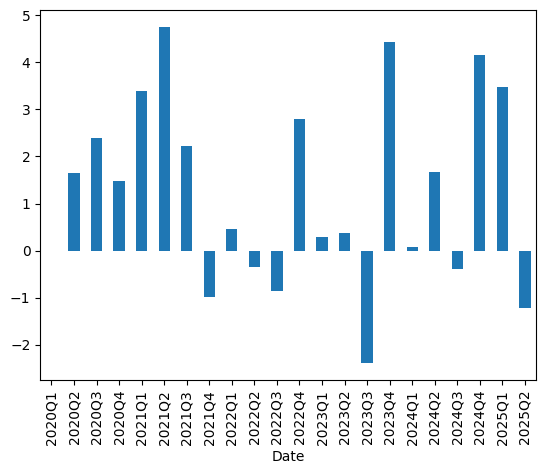

In [149]:
grossMomentum().resample("QE").apply(sharpeRatio).to_period("Q").plot(kind="bar")

C:\Users\jibri\AppData\Local\Temp\ipykernel_19576\3697490901.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return x.mean() / x.std() * np.sqrt(252)


<Axes: xlabel='Date'>

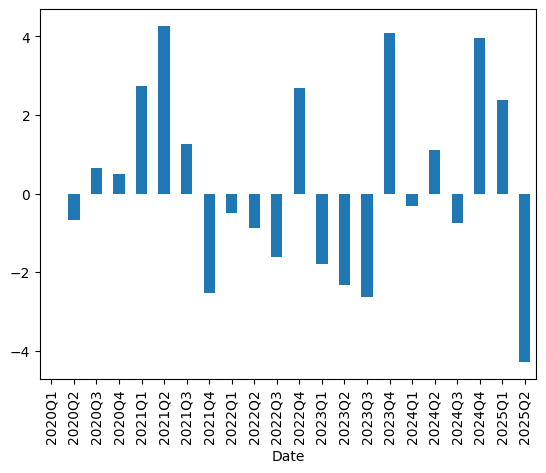

In [139]:
netMomentum().resample("QE").apply(sharpeRatio).to_period("Q").plot(kind="bar")